In [131]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def optimize_portfolio(tickers, start="2020-01-01", trials=100000, plot=True, risk_free=0.02):

    # 1. Download price data
    prices = yf.download(tickers, start=start)["Close"]
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 2. Market benchmark
    sp500 = yf.download("^GSPC", start=start)["Close"]
    sp500_returns = np.log(sp500 / sp500.shift(1)).dropna()

    # 3. Annualized stats (252 trading days)
    mean_returns = log_returns.mean() * 252
    cov_matrix   = log_returns.cov()  * 252

    # 4. Align once, before the loop
    common_idx          = log_returns.index.intersection(sp500_returns.index)
    log_returns_aligned = log_returns.loc[common_idx]
    sp500_aligned       = sp500_returns.loc[common_idx].squeeze().values
    market_var          = np.var(sp500_aligned)

    # 5. Simulate portfolios
    results = []
    for _ in range(trials):
        weights  = np.random.random(len(tickers))
        weights /= np.sum(weights)

        portfolio_returns = (log_returns_aligned @ weights).squeeze().values

        ret    = np.dot(weights, mean_returns)
        vol    = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe = (ret - risk_free) / vol

        cov  = np.cov(portfolio_returns, sp500_aligned)[0, 1]
        beta = cov / market_var

        results.append([ret, vol, sharpe, beta, *weights])

    # 6. Build DataFrame
    columns = ["Return", "Volatility", "Sharpe", "Beta"] + tickers
    pfs     = pd.DataFrame(results, columns=columns)

    # 7. Extract best portfolios
    best_return = pfs.loc[pfs["Return"].idxmax()]
    lowest_vol  = pfs.loc[pfs["Volatility"].idxmin()]
    best_sharpe = pfs.loc[pfs["Sharpe"].idxmax()]

    # 8. Plot
    if plot:
        fig, ax = plt.subplots(figsize=(11, 6))

        sc = ax.scatter(pfs["Volatility"], pfs["Return"],
                        c=pfs["Sharpe"], cmap="RdYlGn",
                        alpha=0.5, s=15, edgecolors="none")
        plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

        ax.scatter(best_return["Volatility"], best_return["Return"],
                   color="#E63946", marker="D", s=120, zorder=5, label="Max Return")
        ax.scatter(lowest_vol["Volatility"],  lowest_vol["Return"],
                   color="#457B9D", marker="D", s=120, zorder=5, label="Min Volatility")
        ax.scatter(best_sharpe["Volatility"], best_sharpe["Return"],
                   color="#2A9D8F", marker="D", s=120, zorder=5, label="Max Sharpe")

        ax.set_xlabel("Volatility (Annualized)", fontsize=11)
        ax.set_ylabel("Return (Annualized)",     fontsize=11)
        ax.set_title("Efficient Frontier — Monte Carlo Simulation",
                     fontsize=13, fontweight="bold")
        ax.legend(framealpha=0.9, fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

    # 9. Clean summary table (HTML - handles any number of tickers)
    from IPython.display import display, HTML

    summary = pd.DataFrame({
        "Max Return":     best_return,
        "Min Volatility": lowest_vol,
        "Max Sharpe":     best_sharpe
    }).T

    fmt               = summary.copy()
    fmt["Return"]     = summary["Return"].map("{:.2%}".format)
    fmt["Volatility"] = summary["Volatility"].map("{:.2%}".format)
    fmt["Sharpe"]     = summary["Sharpe"].map("{:.3f}".format)
    fmt["Beta"]       = summary["Beta"].map("{:.3f}".format)
    for t in tickers:
        fmt[t] = summary[t].map("{:.2%}".format)

    styled = (
        fmt.style
        .set_caption("PORTFOLIO OPTIMIZATION SUMMARY")
        .set_table_styles([
            # Caption
            {"selector": "caption",
             "props": [("font-size", "14px"), ("font-weight", "bold"),
                       ("padding-bottom", "10px"), ("text-align", "left"),
                       ("color", "var(--jp-ui-font-color0, #000)")]},
            # Header row
            {"selector": "thead tr th",
             "props": [("background-color", "#2A9D8F"), ("color", "white"),
                       ("font-size", "12px"), ("padding", "8px 12px"),
                       ("text-align", "center"), ("white-space", "nowrap")]},
            # Index column
            {"selector": "tbody tr th",
             "props": [("font-weight", "600"), ("padding", "8px 14px"),
                       ("white-space", "nowrap"), ("font-size", "12px")]},
            # All cells
            {"selector": "tbody tr td",
             "props": [("padding", "8px 12px"), ("text-align", "center"),
                       ("font-size", "12px"), ("white-space", "nowrap")]},
            # Alternating row colors
            {"selector": "tbody tr:nth-child(odd)",
             "props": [("background-color", "#f8f9fa")]},
            {"selector": "tbody tr:nth-child(even)",
             "props": [("background-color", "#ffffff")]},
            # Hover
            {"selector": "tbody tr:hover",
             "props": [("background-color", "#e8f4f3")]},
            # Scrollable wrapper
            {"selector": "table",
             "props": [("border-collapse", "collapse"), ("width", "100%")]},
        ])
        .set_properties(**{"border": "1px solid #dee2e6"})
    )
    
    # Wrap in scrollable div so wide tables don't break layout
    html = f'<div style="overflow-x:auto; margin: 16px 0;">{styled.to_html()}</div>'
    display(HTML(html))

    return None

[*********************100%***********************]  15 of 15 completed
[*********************100%***********************]  1 of 1 completed


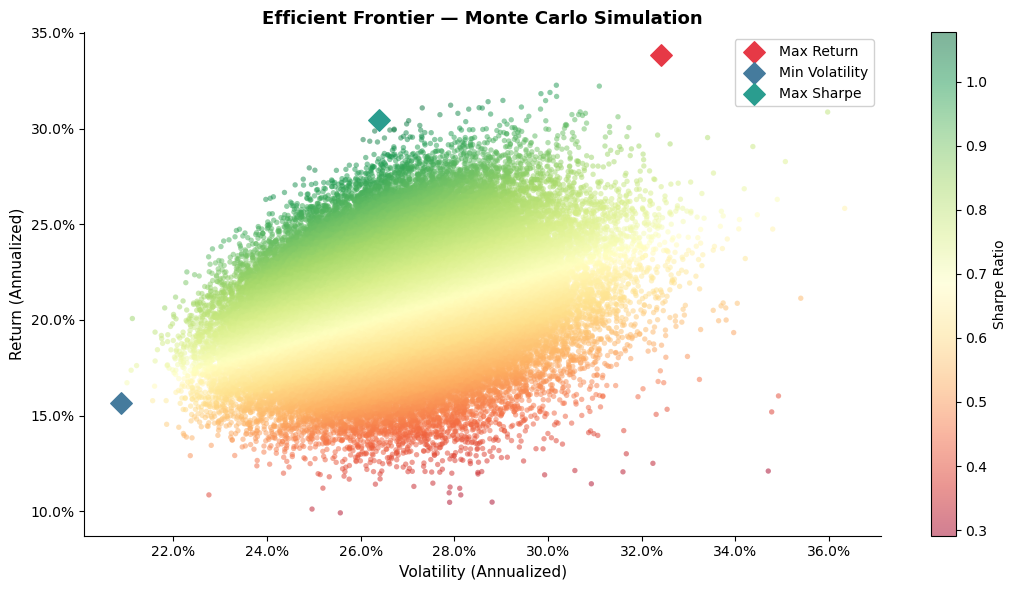

,Return,Volatility,Sharpe,Beta,CMI,TM,NKE,GM,SBUX,AAPL,FSLY,AVGO,NVDA,MSFT,AMZN,GOOGL,TSLA,WMT,META
Max Return,33.84%,32.41%,0.982,1.408,12.42%,2.70%,11.95%,3.45%,2.11%,12.26%,2.25%,2.25%,5.41%,0.66%,20.78%,1.94%,4.45%,17.17%,0.21%
Min Volatility,15.66%,20.87%,0.654,0.958,1.61%,2.63%,0.98%,8.42%,1.86%,5.49%,6.95%,0.18%,17.26%,13.38%,0.59%,0.81%,17.60%,4.26%,17.96%
Max Sharpe,30.44%,26.39%,1.077,1.195,7.56%,4.34%,13.90%,12.94%,0.84%,0.64%,6.80%,1.73%,1.27%,2.96%,15.77%,0.09%,10.98%,8.54%,11.65%


In [133]:
# Example usage:
# Call optimize_portfolio() with a list of stock tickers.
# Optional parameters you can adjust:
#   - start = "YYYY-MM-DD" → change the start date for historical data (default is 2020-01-01)
#   - trials = 10000 → change the number of simulated portfolios (default is 100000)
#   - plot = False → turn off the visualization if you only want printed results
# Just replace the tickers list or adjust the optional parameters to test different portfolios.

optimize_portfolio(["CMI","TM","NKE","GM","SBUX","AAPL","FSLY","AVGO","NVDA","MSFT","AMZN","GOOGL","TSLA","WMT","META"] , start = "2000-05-04")